## Libraries and imports

In [ ]:
# Libraries
import sys
sys.path.append('..')
from feature_selection import data_feature_selection, split_data, split_data_3way, data_feature_selection_3way


import numpy as np
from datetime import datetime
import pandas as pd
import requests
import time
import os
from numpy._core.defchararray import zfill
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit
from sklearn.metrics import classification_report, confusion_matrix, recall_score, f1_score
from sklearn.utils.class_weight import compute_class_weight
from os import scandir, mkdir
import xgboost as xgb
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import precision_recall_curve, average_precision_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input, Conv1D, BatchNormalization, Activation, Add, GlobalAveragePooling1D, GRU
from tensorflow.keras.callbacks import EarlyStopping
import tensorflow as tf
import itertools

#import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
print(tf.config.list_physical_devices("GPU"))

In [ ]:
# Get the dataset
df_ml = pd.read_csv("../../data/processed/DatasetMaster.csv")
df_ml.columns


In [97]:
X_train, X_test, y_train, y_test = split_data(df_ml)

Use StandardScaler to normalize the values

In [98]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Create sequences for temporal models. We use `window_size=24` because the data is hourly.

In [99]:
def create_sequences(X, y, window_size):
    X_seq = []
    y_seq = []

    for i in range(window_size, len(X)):
        X_seq.append(X[i-window_size:i])
        y_seq.append(y.iloc[i])

    return np.array(X_seq), np.array(y_seq)

In [100]:
window_size = 24
X_train_gru, y_train_gru = create_sequences(X_train_scaled, y_train, window_size)
X_test_gru, y_test_gru = create_sequences(X_test_scaled, y_test, window_size)

print(X_train_gru.shape)
print(y_train_gru.shape)

(854287, 24, 45)
(854287,)


We need to calculate class weights in order to train the model using balanced weights, compensating for the class imbalance between flood and non-flood events.

In [102]:
classes = np.unique(y_train_gru)

weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train_gru
)

class_weights = dict(zip(classes, weights))

print(class_weights)

{np.int64(0): np.float64(0.5675247095900713), np.int64(1): np.float64(4.202348392428476)}


## Model creation

In [103]:
# Build GRU model architecture
def build_gru_model(
    window_size,
    n_features,
    gru_units=64,
    dropout_rate=0.3,
    dense_units=32
):

    model = Sequential()

    # GRU layer for temporal sequence learning
    model.add(
        GRU(
            units=gru_units,
            input_shape=(window_size, n_features),
            return_sequences=False
        )
    )

    # Dropout regularization
    model.add(Dropout(dropout_rate))

    # Dense representation layer
    model.add(Dense(dense_units, activation="relu"))

    # Additional dropout
    model.add(Dropout(dropout_rate / 2))

    # Binary classification output
    model.add(Dense(1, activation="sigmoid"))

    # Compile model
    model.compile(
        optimizer="adam",
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    return model

In [104]:
# Initialize GRU model
n_features = X_train_gru.shape[2]

gru_model = build_gru_model(
    window_size=window_size,
    n_features=n_features,
    gru_units=64,
    dropout_rate=0.3,
    dense_units=32
)

gru_model.summary()

c:\Users\eldeivid\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru_1 (GRU)                     │ (None, 64)             │        21,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,425 (91.50 KB)

 Trainable params: 23,425 (91.50 KB)

 Non-trainable params: 0 (0.00 B)

### Train the model

In [105]:
# Early stopping to reduce overfitting
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

# Train GRU model
history_gru = gru_model.fit(
    X_train_gru,
    y_train_gru,
    validation_split=0.2,
    epochs=20,
    batch_size=64,
    callbacks=[early_stop],
    class_weight=class_weights,
    shuffle=False,
    verbose=1
)

Epoch 1/20
10679/10679 ━━━━━━━━━━━━━━━━━━━━ 53s 5ms/step - accuracy: 0.7615 - loss: 0.4599 - val_accuracy: 0.7671 - val_loss: 0.4688
Epoch 2/20
10679/10679 ━━━━━━━━━━━━━━━━━━━━ 59s 6ms/step - accuracy: 0.7660 - loss: 0.4553 - val_accuracy: 0.7100 - val_loss: 0.5288
Epoch 3/20
10679/10679 ━━━━━━━━━━━━━━━━━━━━ 58s 5ms/step - accuracy: 0.7651 - loss: 0.4524 - val_accuracy: 0.6962 - val_loss: 0.5830
Epoch 4/20
10679/10679 ━━━━━━━━━━━━━━━━━━━━ 58s 5ms/step - accuracy: 0.7627 - loss: 0.4506 - val_accuracy: 0.6565 - val_loss: 0.6375
Epoch 5/20
10679/10679 ━━━━━━━━━━━━━━━━━━━━ 58s 5ms/step - accuracy: 0.7631 - loss: 0.4501 - val_accuracy: 0.6434 - val_loss: 0.6520
Epoch 6/20
10679/10679 ━━━━━━━━━━━━━━━━━━━━ 58s 5ms/step - accuracy: 0.7597 - loss: 0.4488 - val_accuracy: 0.6405 - val_loss: 0.6085


### Evaluate the model

In [106]:
y_scores_gru = gru_model.predict(X_test_gru).ravel()

threshold = 0.40
y_pred_gru = (y_scores_gru >= threshold).astype(int)

print(classification_report(y_test_gru, y_pred_gru))
print("PR-AUC:", average_precision_score(y_test_gru, y_scores_gru))

5130/5130 ━━━━━━━━━━━━━━━━━━━━ 7s 1ms/step
              precision    recall  f1-score   support

           0       0.77      0.85      0.81    105180
           1       0.68      0.56      0.61     58953

    accuracy                           0.74    164133
   macro avg       0.72      0.70      0.71    164133
weighted avg       0.74      0.74      0.74    164133

PR-AUC: 0.6649620341706475


5130/5130 ━━━━━━━━━━━━━━━━━━━━ 7s 1ms/step


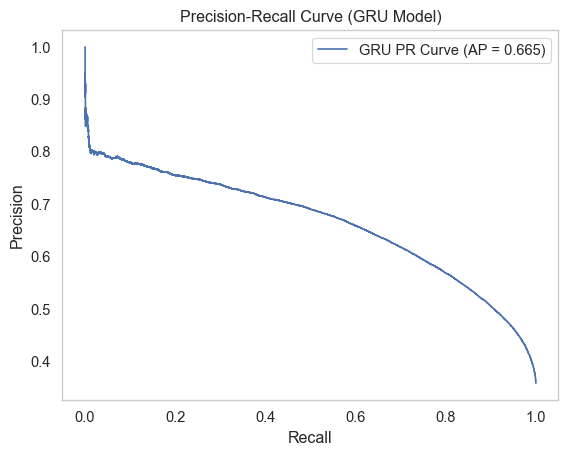

In [107]:
# Get model probabilities for GRU
y_scores_gru = gru_model.predict(X_test_gru).ravel()

# Calculate precision-recall curve
precision_gru, recall_gru, thresholds_gru = precision_recall_curve(
    y_test_gru,
    y_scores_gru
)

# Calculate PR-AUC / Average Precision
ap_gru = average_precision_score(y_test_gru, y_scores_gru)

# Plot
plt.figure()
plt.plot(recall_gru, precision_gru, label=f"GRU PR Curve (AP = {ap_gru:.3f})")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve (GRU Model)")
plt.legend()
plt.grid()
plt.show()

In [108]:
threshold = 0.40
y_pred_gru = (y_scores_gru >= threshold).astype(int)
tn, fp, fn, tp = confusion_matrix(y_test_gru, y_pred_gru).ravel()

print(f"True negatives (predicted safe, was safe): {tn:,}")
print(f"False Positive (predicted incident, was safe): {fp:,} false alarms)")
print(f"False Negatives (predicted safe, was an incident) {fn:,} <- This is the danger, must be low")
print(f"True Positives (predicted incident, was an incident): {tp:,}")

True negatives (predicted safe, was safe): 89,444
False Positive (predicted incident, was safe): 15,736 false alarms)
False Negatives (predicted safe, was an incident) 26,183 <- This is the danger, must be low
True Positives (predicted incident, was an incident): 32,770


In [109]:
def optimize_recall_gru(modelo, X_test_gru, y_test_gru, new_threshold=0.40):

    # The GRU already outputs the probability of class 1 because
    # the final layer uses Dense(1, activation="sigmoid")
    probabilities = modelo.predict(X_test_gru).ravel()

    # Apply new threshold
    adjusted_predictions = (probabilities >= new_threshold).astype(int)

    print("New Threshold report:")
    print(classification_report(y_test_gru, adjusted_predictions))

    # Extract confusion matrix
    tn, fp, fn, tp = confusion_matrix(y_test_gru, adjusted_predictions).ravel()

    print("Adjusted Confusion matrix")
    print(f"True negatives: {tn:,}")
    print(f"False Positive (false alarms): {fp:,} <- may increase as the cost of higher recall")
    print(f"False Negatives  (danger cases): {fn:,} <- should decrease")
    print(f"True Positives (captured incidents): {tp:,} <- should increase")

In [110]:
predicciones_optimas = optimize_recall_gru(gru_model, X_test_gru, y_test_gru, new_threshold=0.40)

5130/5130 ━━━━━━━━━━━━━━━━━━━━ 7s 1ms/step
New Threshold report:
              precision    recall  f1-score   support

           0       0.77      0.85      0.81    105180
           1       0.68      0.56      0.61     58953

    accuracy                           0.74    164133
   macro avg       0.72      0.70      0.71    164133
weighted avg       0.74      0.74      0.74    164133

Adjusted Confusion matrix
True negatives: 89,444
False Positive (Falsas Alarmas): 15,736 <- Subirán (Es el costo)
False Negatives  (EL PELIGRO): 26,183 <- DEBEN BAJAR
True Positives (SALVADOS): 32,770 <- DEBEN SUBIR


In [ ]:
# Function to tune GRU hyperparameters and threshold using validation performance
def hyperparameter_tuning_gru(
    X_train_gru,
    y_train_gru,
    window_size
):

    # Number of features per timestep
    n_features = X_train_gru.shape[2]

    # Hyperparameter search space
    parameters_space = {
        "gru_units": [32, 64],
        "dense_units": [16, 32],
        "dropout_rate": [0.2, 0.3],
        "batch_size": [64]
    }

    # Generate all possible hyperparameter combinations
    combinations = list(itertools.product(
        parameters_space["gru_units"],
        parameters_space["dense_units"],
        parameters_space["dropout_rate"],
        parameters_space["batch_size"]
    ))

    # Create temporal validation split from the training set
    val_size = int(len(X_train_gru) * 0.2)

    X_train_gru_final = X_train_gru[:-val_size]
    y_train_gru_final = y_train_gru[:-val_size]

    X_val_gru = X_train_gru[-val_size:]
    y_val_gru = y_train_gru[-val_size:]

    # Store results for each trained model
    results = []

    # Start execution timer
    start = time.time()

    # Train one model per hyperparameter combination
    for gru_units, dense_units, dropout_rate, batch_size in combinations:

        # Print current experiment configuration
        print(
            f"Training: GRU={gru_units}, "
            f"Dense={dense_units}, "
            f"Dropout={dropout_rate}, "
            f"Batch={batch_size}"
        )

        # Build GRU model with current hyperparameters
        model = build_gru_model(
            window_size=window_size,
            n_features=n_features,
            gru_units=gru_units,
            dense_units=dense_units,
            dropout_rate=dropout_rate
        )

        # Stop early if validation loss stops improving
        early_stop = EarlyStopping(
            monitor="val_loss",
            patience=5,
            restore_best_weights=True
        )

        # Train current model
        history = model.fit(
            X_train_gru_final,
            y_train_gru_final,
            validation_data=(X_val_gru, y_val_gru),
            epochs=20,
            batch_size=batch_size,
            callbacks=[early_stop],
            class_weight=class_weights,
            verbose=0
        )

        # Predict validation probabilities
        probabilities = model.predict(X_val_gru).ravel()

        # Compute PR-AUC using probabilities
        pr_auc = average_precision_score(y_val_gru, probabilities)

        # Search best threshold using validation F1-score
        best_threshold = 0.0
        best_f1 = 0.0
        best_recall = 0.0

        for threshold in np.arange(0.10, 0.91, 0.05):
            predictions = (probabilities >= threshold).astype(int)

            current_f1 = f1_score(y_val_gru, predictions, zero_division=0)
            current_recall = recall_score(y_val_gru, predictions, zero_division=0)

            if current_f1 > best_f1:
                best_f1 = current_f1
                best_recall = current_recall
                best_threshold = threshold

        # Save model configuration and performance
        results.append({
            "gru_units": gru_units,
            "dense_units": dense_units,
            "dropout_rate": dropout_rate,
            "batch_size": batch_size,
            "epochs_trained": len(history.history["loss"]),
            "best_threshold": best_threshold,
            "pr_auc": pr_auc,
            "recall": best_recall,
            "f1": best_f1,
            "model": model
        })

    # End execution timer
    end = time.time()

    # Sort models by PR-AUC in descending order
    results = sorted(results, key=lambda x: x["pr_auc"], reverse=True)

    # Select best model based on PR-AUC
    best_result = results[0]

    # Convert execution time to minutes
    minutos = (end - start) / 60

    # Print tuning summary
    print(f"Tiempo de ejecución: {minutos:.2f} minutos")
    print("LA ARQUITECTURA GANADORA ES:")
    print(f"-> gru_units: {best_result['gru_units']}")
    print(f"-> dense_units: {best_result['dense_units']}")
    print(f"-> dropout_rate: {best_result['dropout_rate']}")
    print(f"-> batch_size: {best_result['batch_size']}")
    print(f"-> epochs_trained: {best_result['epochs_trained']}")
    print(f"-> best_threshold: {best_result['best_threshold']:.2f}")
    print(f"\nMejor Score (PR-AUC) en validación: {best_result['pr_auc']:.4f}")
    print(f"Recall en validación: {best_result['recall']:.4f}")
    print(f"F1 en validación: {best_result['f1']:.4f}")

    # Return best model, best threshold, and all experiment results
    return best_result["model"], best_result["best_threshold"], results, minutos

In [ ]:
# Perform GRU hyperparameter tuning using validation performance
hyperparameterized_gru_model, winner_threshold, gru_tuning_results, execution_minutes = hyperparameter_tuning_gru(
    X_train_gru,
    y_train_gru,
    window_size=window_size
)

Training: GRU=32, Dense=16, Dropout=0.2, Batch=64


c:\Users\eldeivid\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


5340/5340 ━━━━━━━━━━━━━━━━━━━━ 6s 1ms/step
Training: GRU=32, Dense=16, Dropout=0.3, Batch=64


c:\Users\eldeivid\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


5340/5340 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step
Training: GRU=32, Dense=32, Dropout=0.2, Batch=64


...

5340/5340 ━━━━━━━━━━━━━━━━━━━━ 6s 1ms/step
Training: GRU=64, Dense=32, Dropout=0.2, Batch=64


c:\Users\eldeivid\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


5340/5340 ━━━━━━━━━━━━━━━━━━━━ 6s 1ms/step
Training: GRU=64, Dense=32, Dropout=0.3, Batch=64


c:\Users\eldeivid\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


5340/5340 ━━━━━━━━━━━━━━━━━━━━ 6s 1ms/step
Tiempo de ejecución: 60.08 minutos
LA ARQUITECTURA GANADORA ES:
-> gru_units: 32
-> dense_units: 16
-> dropout_rate: 0.2
-> batch_size: 64
-> epochs_trained: 13

Mejor Score (PR-AUC) en validación: 0.4582
Recall en validación: 0.8810
F1 en validación: 0.3939


In [116]:
def final_model_evaluation_gru(modelo_campeon, X_test_gru, y_test_gru, umbral=0.40):
    print("--- STARTING FINAL EVALUATION GRU ON FUTURE DATA (2025) ---")

    # The GRU already outputs probabilities through the sigmoid layer
    probabilidades = modelo_campeon.predict(X_test_gru).ravel()

    # Apply the selected decision threshold
    predicciones_finales = (probabilidades >= umbral).astype(int)

    print(f"\nPERFORMANCE REPORT (UMBRAL: {umbral * 100:.0f}%)")
    print("=" * 50)
    print(classification_report(y_test_gru, predicciones_finales))

    # Final confusion matrix
    tn, fp, fn, tp = confusion_matrix(y_test_gru, predicciones_finales).ravel()

    print("\nFINAL CONFUSION MATRIX:")
    print(f"True negatives (safe hours): {tn:,}")
    print(f"Falsos Positivos (false alarms): {fp:,}")
    print(f"False negatives (missed incidents): {fn:,}")
    print(f"True positives (captured incidents): {tp:,}")

    # Métricas de negocio
    recall_final = tp / (tp + fn) if (tp + fn) > 0 else 0
    precision_final = tp / (tp + fp) if (tp + fp) > 0 else 0

    print("\nBUSINESS METRICS (CIVIL PROTECTION):")
    print(f"-> Capture rate (Recall): {recall_final * 100:.1f}% de las inundaciones fueron detectadas.")
    print(f"-> Precision de Alarma: {precision_final * 100:.1f}% de las alertas fueron reales.")

    return {
        "threshold": umbral,
        "tn": tn,
        "fp": fp,
        "fn": fn,
        "tp": tp,
        "recall": recall_final,
        "precision": precision_final
    }

In [ ]:
def save_run_metrics(
    model_name,
    run_id,
    y_true,
    y_proba,
    execution_time_minutes,
    threshold=0.40,
    csv_path="../results/gru_results.csv",
    extra_info=None
):

    # Create the results directory if it does not exist
    os.makedirs(os.path.dirname(csv_path), exist_ok=True)

    # Convert probabilities into binary predictions using the selected threshold
    y_pred = (y_proba >= threshold).astype(int)

    # Extract confusion matrix values for detailed evaluation
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

    # Store all evaluation metrics and experiment metadata in a dictionary
    row = {
        "timestamp": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
        "model": model_name,
        "run_id": run_id,
        "threshold": threshold,
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "pr_auc": average_precision_score(y_true, y_proba),
        "tn": tn,
        "fp": fp,
        "fn": fn,
        "tp": tp,
        "execution_time_minutes": execution_time_minutes
    }

    # Add optional extra experiment information if provided
    if extra_info is not None:
        row.update(extra_info)

    # Append results to the existing CSV file if it already exists
    if os.path.exists(csv_path):
        results_df = pd.read_csv(csv_path)
        results_df = pd.concat(
            [results_df, pd.DataFrame([row])],
            ignore_index=True
        )

    # Create a new dataframe if this is the first experiment run
    else:
        results_df = pd.DataFrame([row])

    # Save the updated results dataframe to disk
    results_df.to_csv(csv_path, index=False)

    # Return the stored metrics for immediate inspection
    return row

In [ ]:
gru_final_results = final_model_evaluation_gru(
    hyperparameterized_gru_model,
    X_test_gru,
    y_test_gru,
    umbral=winner_threshold
)

--- INICIANDO EVALUACIÓN FINAL GRU SOBRE EL FUTURO (2025) ---
5130/5130 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step

REPORTE DE RENDIMIENTO (UMBRAL: 40%)
              precision    recall  f1-score   support

           0       0.84      0.76      0.80    105180
           1       0.63      0.73      0.68     58953

    accuracy                           0.75    164133
   macro avg       0.74      0.75      0.74    164133
weighted avg       0.76      0.75      0.76    164133


MATRIZ DE CONFUSIÓN DEFINITIVA:
Verdaderos Negativos (Días/Horas Pacíficas): 80,327
Falsos Positivos (Falsas Alarmas): 24,853
Falsos Negativos (Desastres Omitidos): 15,722
Verdaderos Positivos (Desastres Prevenidos): 43,231

MÉTRICAS DE NEGOCIO (PROTECCIÓN CIVIL):
-> Tasa de Captura (Recall): 73.3% de las inundaciones fueron detectadas.
-> Precisión de Alarma: 63.5% de las alertas fueron reales.


5130/5130 ━━━━━━━━━━━━━━━━━━━━ 5s 995us/step


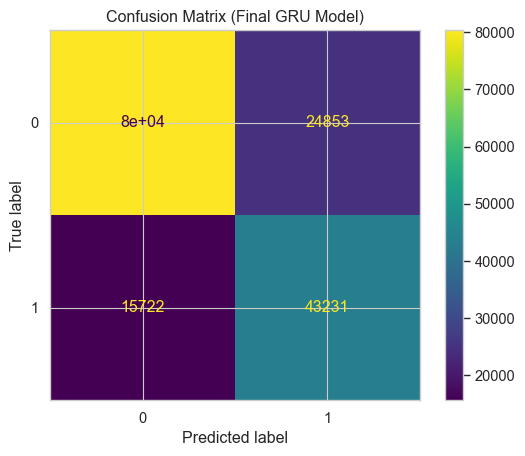

In [118]:
y_pred_final_gru = (
    hyperparameterized_gru_model
    .predict(X_test_gru)
    .ravel() >= 0.40
).astype(int)

ConfusionMatrixDisplay.from_predictions(
    y_test_gru,
    y_pred_final_gru
)

plt.title("Confusion Matrix (Final GRU Model)")
plt.show()

Unlike XGBoost, the GRU model does not provide direct feature-importance metrics because it learns distributed temporal representations.

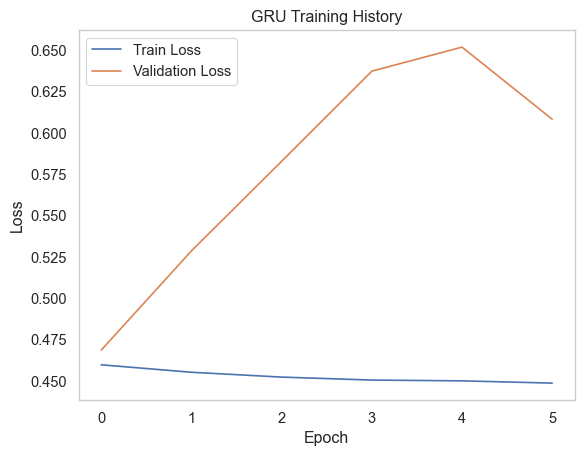

In [119]:
plt.plot(history_gru.history["loss"], label="Train Loss")
plt.plot(history_gru.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("GRU Training History")

plt.legend()
plt.grid()

plt.show()

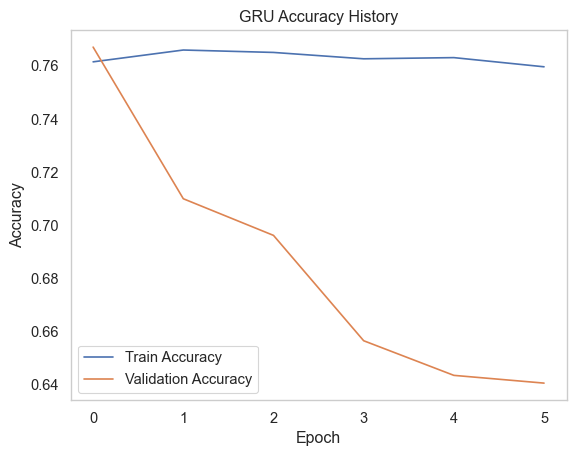

In [120]:
plt.plot(history_gru.history["accuracy"], label="Train Accuracy")
plt.plot(history_gru.history["val_accuracy"], label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("GRU Accuracy History")

plt.legend()
plt.grid()

plt.show()

In [ ]:
y_proba = hyperparameterized_gru_model.predict(X_test_gru).ravel()

save_run_metrics(
    model_name="GRU",
    run_id=datetime.now().strftime("%Y%m%d_%H%M%S"),
    y_true=y_test_gru,
    y_proba=y_proba,
    execution_time_minutes=execution_minutes,
    threshold=winner_threshold,
    csv_path="../results/gru_results.csv"
)